# Лабораторная работа №4 — Статистика случайных процессов

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from scipy.stats import t, norm

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "font.size": 12,
})

## Базовый класс для генерации траекторий

In [2]:
class StochasticProcess:
    def __init__(self, T, N, X0):
        self.T = T
        self.N = N
        self.X0 = X0
        self.dt = T / N
        self.t = np.linspace(0, T, N + 1)
        
    def euler_maruyama(self, b_fn, sigma_fn):
        X = np.zeros(self.N + 1)
        X[0] = self.X0
        dW = np.random.normal(0, np.sqrt(self.dt), self.N)
        for i in range(self.N):
            X[i+1] = X[i] + b_fn(self.t[i], X[i]) * self.dt + sigma_fn(self.t[i], X[i]) * dW[i]
        return self.t, X


## Задача 2. Оценивание параметров в семействе моделей CKLS

In [3]:
# Модель: dX = (θ_1 + θ_2 X)dt + θ_3 X^{θ_4} dW
# Параметры: (1, 2, 0.5, 0.3)
theta_true_ckls = np.array([1.0, 2.0, 0.5, 0.3])
X0_ckls = 2.0
dt_ckls = 1e-4
N_ckls = 10000
T_ckls = N_ckls * dt_ckls

def ckls_b(t, x, theta):
    return theta[0] + theta[1] * x

def ckls_sigma(t, x, theta):
    return theta[2] * np.maximum(x, 1e-8)**theta[3]

def neg_log_likelihood_ckls(theta, X, dt):
    # Ограничения: θ_3 > 0, θ_4 > 0 (чтобы не было NaN)
    if theta[2] <= 0 or theta[3] <= 0:
        return 1e10
    
    X_curr = np.maximum(X[:-1], 1e-8)
    X_next = X[1:]
    
    b = theta[0] + theta[1] * X_curr
    sig2 = (theta[2] * X_curr**theta[3])**2
    
    # -log L
    term1 = ((X_next - X_curr - b * dt)**2) / (sig2 * dt)
    term2 = np.log(2 * np.pi * sig2 * dt)
    
    return 0.5 * np.sum(term1 + term2)

# Проведем n=50 симуляций
n_sim = 50
results_ckls = np.zeros((n_sim, 4))

np.random.seed(SEED)
for k in range(n_sim):
    # Генерация
    proc = StochasticProcess(T_ckls, N_ckls, X0_ckls)
    t_data, x_data = proc.euler_maruyama(
        lambda t, x: ckls_b(t, x, theta_true_ckls),
        lambda t, x: ckls_sigma(t, x, theta_true_ckls)
    )
    
    # Оптимизация (стартовая точка - истинная + шум для ускорения)
    theta_guess = theta_true_ckls * (1 + 0.1 * np.random.randn(4))
    theta_guess[2] = max(theta_guess[2], 0.1)
    theta_guess[3] = max(theta_guess[3], 0.1)
    
    res = minimize(
        neg_log_likelihood_ckls, 
        x0=theta_guess, 
        args=(x_data, dt_ckls),
        method='L-BFGS-B',
        bounds=[(None, None), (None, None), (1e-5, None), (1e-5, None)]
    )
    results_ckls[k] = res.x

# Статистика и 95% ДИ
mean_est = results_ckls.mean(axis=0)
std_est = results_ckls.std(axis=0, ddof=1)
t_val = t.ppf(0.975, df=n_sim-1)
margin = t_val * std_est / np.sqrt(n_sim)

df_ckls = pd.DataFrame({
    'True': theta_true_ckls,
    'Mean Est': mean_est,
    'Std Error': std_est / np.sqrt(n_sim),
    'CI Lower': mean_est - margin,
    'CI Upper': mean_est + margin
}, index=['θ_1', 'θ_2', 'θ_3', 'θ_4'])

display(df_ckls)


,True,Mean Est,Std Error,CI Lower,CI Upper
θ_1,1.0,1.034065,0.179072,0.674207,1.393924
θ_2,2.0,1.986251,0.028638,1.928700,2.043802
θ_3,0.5,0.498953,0.001369,0.496201,0.501704
θ_4,0.3,0.301557,0.001541,0.298460,0.304653


## Задача 3. Локальная линеаризация (Метод Озаки)

In [4]:
# Модель Вазичека: dX = θ_1(θ_2 - X)dt + θ_3 dW
theta_true_vas = np.array([3.0, 2.0, 0.5])
X0_vas = 5.0
T_vas = 10.0

def vasicek_b(t, x, theta):
    return theta[0] * (theta[1] - x)

def vasicek_sigma(t, x, theta):
    return theta[2]

def neg_ll_euler_vas(theta, X, dt):
    if theta[2] <= 0: return 1e10
    X_curr = X[:-1]
    X_next = X[1:]
    b = theta[0] * (theta[1] - X_curr)
    sig2 = theta[2]**2
    term1 = ((X_next - X_curr - b * dt)**2) / (sig2 * dt)
    term2 = np.log(2 * np.pi * sig2 * dt)
    return 0.5 * np.sum(term1 + term2)

def neg_ll_ozaki_vas(theta, X, dt):
    if theta[0] <= 0 or theta[2] <= 0: return 1e10
    X_curr = X[:-1]
    X_next = X[1:]
    
    # E[X_{i+1}|X_i] и Var
    e_kappa_dt = np.exp(-theta[0] * dt)
    M = X_curr * e_kappa_dt + theta[1] * (1 - e_kappa_dt)
    V = (theta[2]**2 / (2 * theta[0])) * (1 - np.exp(-2 * theta[0] * dt))
    
    term1 = ((X_next - M)**2) / V
    term2 = np.log(2 * np.pi * V)
    return 0.5 * np.sum(term1 + term2)

dt_list = [10**-1, 10**-2, 10**-3]
M_sim = 20

res_euler = {dt: [] for dt in dt_list}
res_ozaki = {dt: [] for dt in dt_list}

np.random.seed(SEED)
for dt in dt_list:
    N = int(T_vas / dt)
    for _ in range(M_sim):
        proc = StochasticProcess(T_vas, N, X0_vas)
        proc.dt = dt
        _, x_data = proc.euler_maruyama(
            lambda t, x: vasicek_b(t, x, theta_true_vas),
            lambda t, x: vasicek_sigma(t, x, theta_true_vas)
        )
        
        guess = theta_true_vas * (1 + 0.1 * np.random.randn(3))
        guess[0] = max(guess[0], 0.1)
        guess[2] = max(guess[2], 0.1)
        
        opt_e = minimize(neg_ll_euler_vas, guess, args=(x_data, dt), method='L-BFGS-B', bounds=[(1e-3, None), (None, None), (1e-3, None)])
        opt_o = minimize(neg_ll_ozaki_vas, guess, args=(x_data, dt), method='L-BFGS-B', bounds=[(1e-3, None), (None, None), (1e-3, None)])
        
        res_euler[dt].append(opt_e.x)
        res_ozaki[dt].append(opt_o.x)

for dt in dt_list:
    e_mean = np.mean(res_euler[dt], axis=0)
    o_mean = np.mean(res_ozaki[dt], axis=0)
    print(f"\n--- dt = {dt} ---")
    print(f"True:   {theta_true_vas}")
    print(f"Euler:  {np.round(e_mean, 3)} (MSE: {np.mean(np.sum((res_euler[dt] - theta_true_vas)**2, axis=1)):.4f})")
    print(f"Ozaki:  {np.round(o_mean, 3)} (MSE: {np.mean(np.sum((res_ozaki[dt] - theta_true_vas)**2, axis=1)):.4f})")



--- dt = 0.1 ---
True:   [3.  2.  0.5]
Euler:  [2.9   2.014 0.487] (MSE: 0.1312)
Ozaki:  [3.437 2.014 0.573] (MSE: 0.4389)

--- dt = 0.01 ---
True:   [3.  2.  0.5]
Euler:  [3.094 2.005 0.501] (MSE: 0.1236)
Ozaki:  [3.144 2.005 0.509] (MSE: 0.1427)

--- dt = 0.001 ---
True:   [3.  2.  0.5]
Euler:  [3.134 2.003 0.5  ] (MSE: 0.1458)
Ozaki:  [3.137 2.003 0.5  ] (MSE: 0.1481)


## Задача 4. Метод Кесслера (Модель Халла-Уайта)

In [5]:
# Модель: dX = θ_1 t (θ_2 √t - X)dt + θ_3 t dW
theta_true_hw = np.array([3.0, 1.0, 0.3])
X0_hw = 2.0
dt_hw = 1e-3
T_hw = 1.0
N_hw = int(T_hw / dt_hw)

def hw_b(t, x, theta):
    return theta[0] * t * (theta[1] * np.sqrt(max(t, 1e-8)) - x)

def hw_sigma(t, x, theta):
    return theta[2] * t

# Метод Кесслера
def neg_ll_kessler_hw(theta, X, t_arr, dt):
    if theta[2] <= 0: return 1e10
    X_curr = X[:-1]
    X_next = X[1:]
    t_curr = np.maximum(t_arr[:-1], 1e-8)
    
    b = theta[0] * t_curr * (theta[1] * np.sqrt(t_curr) - X_curr)
    bx = -theta[0] * t_curr
    sig2 = (theta[2] * t_curr)**2
    bxx = 0
    sig2_x = 0
    sig2_xx = 0
    
    m_x = X_curr + b * dt + 0.5 * (b * bx + 0.5 * sig2 * bxx) * dt**2
    V_x = X_curr**2 + (2 * b * X_curr + sig2) * dt + \
          0.5 * (2 * b * (bx * X_curr + b) + sig2 * (2 * bx)) * dt**2 - m_x**2
          
    V_x = np.maximum(V_x, 1e-12)
    
    term1 = ((X_next - m_x)**2) / V_x
    term2 = np.log(2 * np.pi * V_x)
    return 0.5 * np.sum(term1 + term2)

np.random.seed(SEED)
proc = StochasticProcess(T_hw, N_hw, X0_hw)
t_hw, x_hw = proc.euler_maruyama(
    lambda t, x: hw_b(t, x, theta_true_hw),
    lambda t, x: hw_sigma(t, x, theta_true_hw)
)

guess = np.array([3.0, 1.0, 0.3])
res_hw = minimize(
    neg_ll_kessler_hw, guess, args=(x_hw, t_hw, dt_hw),
    method='BFGS' # BFGS отдает hess_inv
)

theta_est_hw = res_hw.x
cov_matrix = res_hw.hess_inv

std_errs = np.sqrt(np.diag(cov_matrix))
margin = 1.96 * std_errs

df_hw = pd.DataFrame({
    'True': theta_true_hw,
    'Est Kessler': theta_est_hw,
    'Std Err': std_errs,
    'CI Lower': theta_est_hw - margin,
    'CI Upper': theta_est_hw + margin
}, index=['θ_1', 'θ_2', 'θ_3'])

display(df_hw)
print("\nCovariance Matrix:")
print(cov_matrix)


,True,Est Kessler,Std Err,CI Lower,CI Upper
θ_1,3.0,2.983577,0.358202,2.281500,3.685653
θ_2,1.0,0.994197,0.019144,0.956675,1.031719
θ_3,0.3,0.292957,0.940692,-1.550800,2.136714



Covariance Matrix:
[[ 1.28308819e-01 -6.75668705e-03 -3.36883845e-01]
 [-6.75668705e-03  3.66494339e-04  1.77459954e-02]
 [-3.36883845e-01  1.77459954e-02  8.84902227e-01]]


## Задача 5. Исследование схем наблюдений

In [6]:
# Базовая модель OU: dX = 3(2 - X)dt + 0.5 dW
theta_true_ou = np.array([3.0, 2.0, 0.5])

# Явные формулы MLE для OU (ускорят сбор статистики)
def mle_ou(X, dt):
    n = len(X) - 1
    X_prev = X[:-1]
    X_curr = X[1:]
    
    sum_prev = np.sum(X_prev)
    sum_curr = np.sum(X_curr)
    sum_prev_sq = np.sum(X_prev**2)
    sum_cross = np.sum(X_prev * X_curr)
    
    den = n * sum_prev_sq - sum_prev**2
    if den == 0: return np.array([1.0, 1.0, 1.0])
    
    b1 = (n * sum_cross - sum_curr * sum_prev) / den
    b2 = (sum_curr - b1 * sum_prev) / (n * (1 - b1))
    
    if b1 <= 0 or b1 >= 1: 
        kappa = 1e-4 # fallback
    else:
        kappa = -np.log(b1) / dt
        
    theta_mle = b2
    
    residuals = X_curr - b1 * X_prev - b2 * (1 - b1)
    b3 = np.mean(residuals**2)
    
    # sigma^2 = 2 * kappa * b3 / (1 - e^{-2*kappa*dt})
    term = 1 - np.exp(-2 * kappa * dt)
    if term <= 0: sigma = 1e-4
    else: sigma = np.sqrt(2 * kappa * b3 / term)
    
    return np.array([kappa, theta_mle, sigma])

np.random.seed(SEED)

# 1. Large Sample: dt = 0.1, n in {100, 500, 1000, 2000} -> T in {10, 50, 100, 200}
n_large = [100, 500, 1000, 2000, 5000]
dt_ls = 0.1
var_kappa_ls, var_theta_ls, var_sigma_ls = [], [], []

for n in n_large:
    ests = []
    T = n * dt_ls
    for _ in range(50):
        proc = StochasticProcess(T, n, 2.0)
        _, X = proc.euler_maruyama(lambda t,x: 3*(2-x), lambda t,x: 0.5)
        ests.append(mle_ou(X, dt_ls))
    ests = np.array(ests)
    var_kappa_ls.append(np.var(ests[:,0]))
    var_theta_ls.append(np.var(ests[:,1]))
    var_sigma_ls.append(np.var(ests[:,2]))

# 2. High-Frequency: T = 5.0, n in {100, 500, 1000, 2000} -> dt in {0.05, 0.01, ...}
T_hf = 5.0
n_hf = [100, 500, 1000, 2000, 5000]
var_kappa_hf, var_theta_hf, var_sigma_hf = [], [], []

for n in n_hf:
    ests = []
    dt_hf = T_hf / n
    for _ in range(50):
        proc = StochasticProcess(T_hf, n, 2.0)
        _, X = proc.euler_maruyama(lambda t,x: 3*(2-x), lambda t,x: 0.5)
        ests.append(mle_ou(X, dt_hf))
    ests = np.array(ests)
    var_kappa_hf.append(np.var(ests[:,0]))
    var_theta_hf.append(np.var(ests[:,1]))
    var_sigma_hf.append(np.var(ests[:,2]))


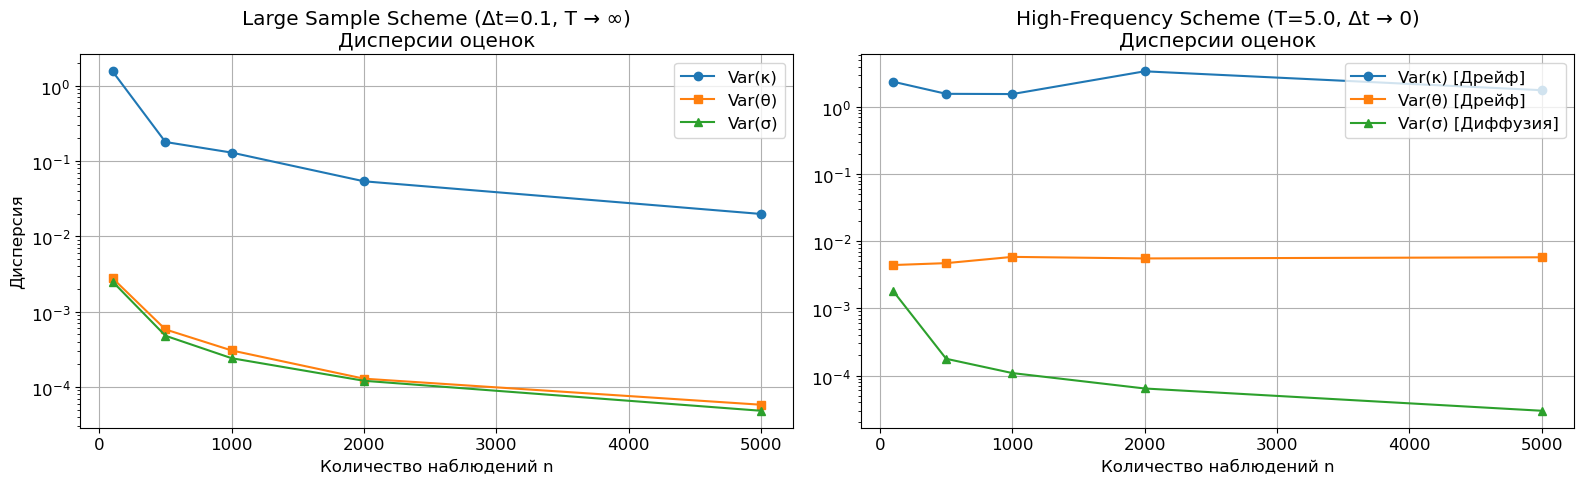

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Large Sample (Дисперсии убывают с ростом N, так как T растет)
ax1.plot(n_large, var_kappa_ls, 'o-', label='Var(κ)')
ax1.plot(n_large, var_theta_ls, 's-', label='Var(θ)')
ax1.plot(n_large, var_sigma_ls, '^-', label='Var(σ)')
ax1.set_title('Large Sample Scheme (Δt=0.1, T → ∞)\nДисперсии оценок')
ax1.set_xlabel('Количество наблюдений n')
ax1.set_ylabel('Дисперсия')
ax1.set_yscale('log')
ax1.legend()

# High Frequency (T=5.0 фиксировано, dt -> 0)
ax2.plot(n_hf, var_kappa_hf, 'o-', label='Var(κ) [Дрейф]')
ax2.plot(n_hf, var_theta_hf, 's-', label='Var(θ) [Дрейф]')
ax2.plot(n_hf, var_sigma_hf, '^-', label='Var(σ) [Диффузия]')
ax2.set_title('High-Frequency Scheme (T=5.0, Δt → 0)\nДисперсии оценок')
ax2.set_xlabel('Количество наблюдений n')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()


**Вывод (Схемы наблюдений):**
- **Large Sample:** При увеличении окна наблюдений $T \to \infty$ дисперсии оценок всех параметров (и дрейфа, и диффузии) убывают к нулю (асимптотическая состоятельность).
- **High Frequency:** При фиксированном $T$ и $\Delta t \to 0$ оценка диффузии $\sigma$ сходится быстро (за счет квадратичной вариации), дисперсия стремится к 0. Но дисперсия оценок дрейфа ($\kappa, \theta$) выходит на плато (константу) и не стремится к нулю. Это подтверждает теоретический факт: для состоятельной оценки дрейфа необходимо долгое наблюдение (эргодичность), а не частое.